# 01: CATE Foundations and Potential Outcomes

We build the conceptual foundation for the EconML tutorial series. Before fitting DML, causal forests, DR learners, or meta-learners, we need a precise answer to a simpler question:

> What treatment effect are we trying to estimate?

EconML is especially useful when the effect is not the same for everyone. That means we need to understand:

- potential outcomes;
- the fundamental missing-data problem in causal inference;
- average treatment effects versus conditional treatment effects;
- why raw treated-control comparisons are usually not causal in observational data;
- why CATE estimates are useful for segmentation and treatment targeting.

The dataset is synthetic, so both potential outcomes are known inside the notebook. Real data would hide one potential outcome for each row. The synthetic setup gives us a clean teaching sandbox.

## Learning Goals

By the end, you should be able to:

- Define potential outcomes `Y(0)` and `Y(1)`.
- Explain why individual treatment effects are not directly observed in real data.
- Distinguish ATE, ATT, ATC, CATE, and ITE-style language.
- Diagnose confounding and overlap before estimating treatment effects.
- Show why one ATE can hide meaningful segment-level differences.
- Use an oracle synthetic dataset to connect CATE to treatment targeting.
- Understand why later EconML notebooks need nuisance models and effect modifiers.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic or semi-synthetic treatment-effect datasets with observable oracle effects to study **CATE Foundations And Potential Outcomes**. Known treatment-effect surfaces let us check whether CATE, policy, interval, and interpretability tools recover the right heterogeneity pattern.

Read each row as a customer, user, patient, seller, or operational unit with covariates measured before treatment. Effect modifiers drive heterogeneity, while controls and propensities create the observational difficulty. The experiment focuses on effect heterogeneity. The target is whether treatment works on average and where it works, but where and for whom it works. The experiment uses observable oracle potential outcomes so the missing-counterfactual problem can be studied directly.

The oracle columns are teaching instruments. In a real deployment, those columns would not exist, so diagnostics, overlap checks, uncertainty, and sensitivity analysis become essential.


## Mathematical Foundation

<!-- math-foundation-note -->

EconML is built around conditional treatment effects. For binary treatment,

$$
\tau(x)=\mathbb{E}\{Y(1)-Y(0)\mid X=x\}.
$$

The average treatment effect is

$$
\tau_{ATE}=\mathbb{E}\{\tau(X)\}.
$$

The estimators differ in how they learn nuisance functions, represent $\tau(x)$, and quantify uncertainty. The causal assumptions come from the design.


## Why Foundations Matter for EconML

EconML estimators can produce a treatment-effect estimate for every row. That is powerful, but it is easy to misuse if the estimand is unclear.

A row-level CATE estimate is not magic personalization. It is an estimate of an expected contrast under assumptions:

`E[Y(1) - Y(0) | X = x]`

The conditioning features `X` define the heterogeneity we want to learn. The controls `W` help adjust for confounding. Later notebooks will fit estimators; this lesson focuses on what those estimators are trying to recover.




## Tutorial Workflow

#### Setup

The code below imports the libraries, creates output folders, checks the EconML version, and sets plotting defaults. We keep this lesson estimator-light, but the import check confirms the tutorial environment is still ready for the later EconML notebooks.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings
import importlib.metadata as importlib_metadata

# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")

import numpy as np

# Compatibility shim for older SHAP/EconML imports under NumPy 2.x.
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
if not hasattr(np, "obj2sctype"):
    def _numpy_obj2sctype_compat(rep, default=None):
        try:
            return np.dtype(rep).type
        except TypeError:
            return default

    np.obj2sctype = _numpy_obj2sctype_compat
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    import econml
    ECONML_AVAILABLE = True
    ECONML_VERSION = getattr(econml, "__version__", "unknown")
except Exception as exc:
    ECONML_AVAILABLE = False
    ECONML_VERSION = f"import failed: {type(exc).__name__}: {exc}"

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"EconML available: {ECONML_AVAILABLE}")
print(f"EconML version: {ECONML_VERSION}")
print(f"Figures will be saved to: {FIGURE_DIR.resolve()}")
print(f"Tables will be saved to: {TABLE_DIR.resolve()}")


EconML available: True
EconML version: 0.16.0
Figures will be saved to: /home/apex/Documents/portfolio/notebooks/tutorials/econml/outputs/figures
Tables will be saved to: /home/apex/Documents/portfolio/notebooks/tutorials/econml/outputs/tables


The setup confirms that the environment is ready. Every saved output from this lesson uses a `01_` prefix.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


### Estimand Vocabulary

The next table defines the core treatment-effect quantities used throughout the EconML series. The names look similar, but they answer different questions.

| term | plain meaning | conditioning | observed in real data |
| --- | --- | --- | --- |
| Potential outcome Y(0) | Outcome the unit would have under no treatment. | unit-level hypothetical | only if T = 0 |
| Potential outcome Y(1) | Outcome the unit would have under treatment. | unit-level hypothetical | only if T = 1 |
| ITE-style contrast | Y(1) - Y(0) for a unit. | single unit | no, because one potential outcome is missing |
| ATE | Average treatment effect in the whole population. | none or full population | estimated under assumptions |
| ATT | Average treatment effect among treated units. | T = 1 population | estimated under assumptions |
| ATC | Average treatment effect among control units. | T = 0 population | estimated under assumptions |
| CATE | Average treatment effect for units with features X = x. | effect modifiers X | estimated under assumptions |


The key EconML target is usually CATE. The average effect still matters, but heterogeneity is the reason to reach for a specialized library.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


### Identification Assumptions

Potential-outcomes notation does not identify effects by itself. We need assumptions that connect observed data to the missing counterfactual outcomes.

| assumption | plain meaning | why it matters |
| --- | --- | --- |
| Consistency | The observed outcome equals the potential outcome under the treatment actually received. | Lets us write Y = T*Y(1) + (1-T)*Y(0). |
| No interference | One unit's treatment does not change another unit's potential outcomes. | Lets each row be treated as its own treatment-effect problem. |
| Ignorability / unconfoundedness | After observed covariates, treatment assignment is as-if random. | Lets observed controls stand in for the missing counterfactual assignment process. |
| Overlap / positivity | Every relevant covariate region has some chance of treatment and control. | Lets us compare like with like instead of extrapolating everywhere. |
| Correct feature timing | X and W are measured before treatment and are not outcome leakage. | Prevents post-treatment or future variables from contaminating CATE estimates. |


These assumptions are not EconML-specific; they are causal inference assumptions. EconML gives estimators, not automatic identification guarantees.

The table is useful because it compresses the evidence into a form that can be compared, audited, and tied back to the causal question.
<!-- result-implication-expanded -->


#### Simulate Potential Outcomes

We now create a synthetic dataset where both `Y0` and `Y1` are known. The analyst would normally observe only one of them, but we keep both in the notebook so the foundations are visible.

In [2]:
N = 5_000

baseline_need = rng.normal(0, 1, size=N)
prior_engagement = rng.normal(0, 1, size=N)
account_tenure = rng.normal(0, 1, size=N)
friction_score = rng.normal(0, 1, size=N)
region_risk = rng.binomial(1, 0.35, size=N)
high_need_segment = (baseline_need > 0).astype(int)

# Baseline outcome under no treatment.
shared_noise = rng.normal(0, 0.70, size=N)
y0 = (
    0.65 * baseline_need
    + 0.35 * prior_engagement
    - 0.25 * account_tenure
    - 0.35 * friction_score
    - 0.15 * region_risk
    + shared_noise
)

# Heterogeneous treatment effect. Some units benefit more than others.
true_cate = (
    0.30
    + 0.45 * high_need_segment
    + 0.25 * prior_engagement
    - 0.35 * friction_score
    + 0.10 * baseline_need
    - 0.05 * region_risk
)
y1 = y0 + true_cate

# Observational treatment assignment: treatment is more likely for some higher-need and higher-friction units.
propensity = 1 / (1 + np.exp(-(
    -0.20
    + 0.75 * baseline_need
    + 0.50 * prior_engagement
    - 0.30 * account_tenure
    + 0.45 * friction_score
    + 0.25 * region_risk
)))
treatment = rng.binomial(1, propensity, size=N)

observed_outcome = np.where(treatment == 1, y1, y0)
missing_counterfactual = np.where(treatment == 1, y0, y1)

potential_df = pd.DataFrame(
    {
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "account_tenure": account_tenure,
        "friction_score": friction_score,
        "region_risk": region_risk,
        "high_need_segment": high_need_segment,
        "propensity": propensity,
        "treatment": treatment,
        "y0": y0,
        "y1": y1,
        "observed_outcome": observed_outcome,
        "missing_counterfactual": missing_counterfactual,
        "true_cate": true_cate,
    }
)

analyst_df = potential_df.drop(columns=["y0", "y1", "missing_counterfactual", "true_cate", "propensity"]).copy()

potential_df.to_csv(TABLE_DIR / "01_potential_outcomes_teaching_data_with_truth.csv", index=False)
analyst_df.to_csv(TABLE_DIR / "01_analyst_observed_data.csv", index=False)

display(potential_df.head())


,baseline_need,prior_engagement,account_tenure,friction_score,region_risk,high_need_segment,propensity,treatment,y0,y1,observed_outcome,missing_counterfactual,true_cate
0,-0.7931,-1.2466,-0.1389,0.5943,1,0,0.2975,0,-2.4796,-2.8285,-2.4796,-2.8285,-0.3490
1,0.2406,0.1167,-1.5248,1.3611,0,1,0.7519,0,1.6533,1.9801,1.6533,1.9801,0.3268
2,-1.8963,0.0111,-1.5855,1.2671,0,0,0.3610,1,-0.7512,-1.0815,-1.0815,-0.7512,-0.3303
3,1.3958,-0.2102,-0.0577,0.6624,0,1,0.7421,1,0.2778,0.8830,0.8830,0.2778,0.6052
4,0.6383,-0.4979,1.3250,0.0489,0,1,0.4144,0,0.1120,0.7842,0.1120,0.7842,0.6722


The full example dataframe contains both potential outcomes and the true CATE. The analyst-facing dataframe removes those truth columns because real data would not contain them.

#### Data Dictionary

The data dictionary separates observed analyst columns from oracle-only teaching columns. This is a habit worth keeping in all synthetic tutorials.

| column | role | visible to analyst |
| --- | --- | --- |
| baseline_need | observed pre-treatment feature | True |
| prior_engagement | observed pre-treatment feature | True |
| account_tenure | observed pre-treatment feature | True |
| friction_score | observed pre-treatment feature | True |
| region_risk | observed pre-treatment feature | True |
| high_need_segment | observed effect-modifier segment | True |
| treatment | observed binary treatment | True |
| observed_outcome | observed factual outcome | True |
| propensity | true treatment probability from simulator | False |
| y0 | potential outcome under control | False |
| y1 | potential outcome under treatment | False |
| missing_counterfactual | the potential outcome not observed for the assigned treatment | False |
| true_cate | Y(1) - Y(0) in the simulator | False |


The oracle-only columns are what make the lesson possible. In real data, these columns are precisely what causal inference tries to reason about indirectly.




## Reporting and Takeaways

### Basic Dataset Summary

Before estimands, we check the basic shape of the data and the distribution of treatment. This also gives the true effect quantities available only in the synthetic setup.

In [3]:
true_ate = potential_df["true_cate"].mean()
true_att = potential_df.loc[potential_df["treatment"] == 1, "true_cate"].mean()
true_atc = potential_df.loc[potential_df["treatment"] == 0, "true_cate"].mean()

basic_summary = pd.DataFrame(
    [
        {"quantity": "rows", "value": len(potential_df)},
        {"quantity": "treatment_rate", "value": potential_df["treatment"].mean()},
        {"quantity": "observed_outcome_mean", "value": potential_df["observed_outcome"].mean()},
        {"quantity": "true_ate", "value": true_ate},
        {"quantity": "true_att", "value": true_att},
        {"quantity": "true_atc", "value": true_atc},
        {"quantity": "true_cate_std", "value": potential_df["true_cate"].std()},
        {"quantity": "share_negative_true_cate", "value": (potential_df["true_cate"] < 0).mean()},
    ]
)

basic_summary.to_csv(TABLE_DIR / "01_basic_summary.csv", index=False)
display(basic_summary)


,quantity,value
0,rows,"5,000.0000"
1,treatment_rate,0.4904
2,observed_outcome_mean,0.2168
3,true_ate,0.5050
4,true_att,0.5771
5,true_atc,0.4355
6,true_cate_std,0.5345
7,share_negative_true_cate,0.1762


The ATE is positive, but the CATE standard deviation and negative-effect share tell us there is meaningful heterogeneity. A single average will hide some of that structure.



### The Fundamental Missing-Data Problem

For each unit, we observe only the potential outcome corresponding to the treatment actually received. The other potential outcome is counterfactual.

In [4]:
observability_example = potential_df.head(10).copy()
observability_example["observed_y0"] = np.where(observability_example["treatment"] == 0, observability_example["y0"], np.nan)
observability_example["observed_y1"] = np.where(observability_example["treatment"] == 1, observability_example["y1"], np.nan)
observability_example["unobserved_counterfactual_label"] = np.where(
    observability_example["treatment"] == 1,
    "Y(0) is missing",
    "Y(1) is missing",
)

observability_display = observability_example[
    ["treatment", "observed_outcome", "observed_y0", "observed_y1", "unobserved_counterfactual_label", "true_cate"]
]
observability_display.to_csv(TABLE_DIR / "01_fundamental_problem_example.csv", index=False)
display(observability_display)


,treatment,observed_outcome,observed_y0,observed_y1,unobserved_counterfactual_label,true_cate
0,0,-2.4796,-2.4796,NaN,Y(1) is missing,-0.3490
1,0,1.6533,1.6533,NaN,Y(1) is missing,0.3268
2,1,-1.0815,NaN,-1.0815,Y(0) is missing,-0.3303
3,1,0.8830,NaN,0.8830,Y(0) is missing,0.6052
4,0,0.1120,0.1120,NaN,Y(1) is missing,0.6722
5,1,1.2231,NaN,1.2231,Y(0) is missing,0.2124
6,0,-0.0916,-0.0916,NaN,Y(1) is missing,0.1911
7,1,1.5813,NaN,1.5813,Y(0) is missing,0.6849
8,1,-0.1073,NaN,-0.1073,Y(0) is missing,0.6197
9,0,-0.9525,-0.9525,NaN,Y(1) is missing,0.0157


The `true_cate` column is shown only because this is a simulation. In real data, we would not observe both `Y(0)` and `Y(1)` for the same row.



### True Effect Quantities from Oracle Data

With synthetic potential outcomes, we can compute ATE, ATT, ATC, and segment CATE directly. This gives us a target for later estimation notebooks.

In [5]:
true_effect_summary = pd.DataFrame(
    [
        {
            "estimand": "ATE",
            "value": true_ate,
            "population": "all units",
            "formula in this simulation": "mean(Y1 - Y0)",
        },
        {
            "estimand": "ATT",
            "value": true_att,
            "population": "treated units",
            "formula in this simulation": "mean(Y1 - Y0 | T=1)",
        },
        {
            "estimand": "ATC",
            "value": true_atc,
            "population": "control units",
            "formula in this simulation": "mean(Y1 - Y0 | T=0)",
        },
    ]
)

true_effect_summary.to_csv(TABLE_DIR / "01_true_effect_summary.csv", index=False)
display(true_effect_summary)


,estimand,value,population,formula in this simulation
0,ATE,0.5050,all units,mean(Y1 - Y0)
1,ATT,0.5771,treated units,mean(Y1 - Y0 | T=1)
2,ATC,0.4355,control units,mean(Y1 - Y0 | T=0)


ATE, ATT, and ATC differ because treatment assignment is related to features that also modify treatment effects. This is common in targeted observational systems.

### Raw Difference versus True ATE

The raw treated-control difference compares observed outcomes by treatment group. It is easy to compute, but it is not automatically causal.

In [6]:
# Save the artifacts produced by the Raw Difference Versus True ATE section.
raw_group_summary = (
    potential_df.groupby("treatment")
    .agg(
        rows=("observed_outcome", "size"),
        mean_observed_outcome=("observed_outcome", "mean"),
        mean_true_cate=("true_cate", "mean"),
        mean_propensity=("propensity", "mean"),
    )
    .reset_index()
)

raw_difference = (
    raw_group_summary.loc[raw_group_summary["treatment"] == 1, "mean_observed_outcome"].iloc[0]
    - raw_group_summary.loc[raw_group_summary["treatment"] == 0, "mean_observed_outcome"].iloc[0]
)

raw_vs_truth = pd.DataFrame(
    [
        {"quantity": "raw treated-control difference", "value": raw_difference},
        {"quantity": "true ATE", "value": true_ate},
        {"quantity": "raw bias versus true ATE", "value": raw_difference - true_ate},
    ]
)

raw_group_summary.to_csv(TABLE_DIR / "01_raw_group_summary.csv", index=False)
raw_vs_truth.to_csv(TABLE_DIR / "01_raw_difference_vs_truth.csv", index=False)

display(raw_group_summary)
display(raw_vs_truth)


,treatment,rows,mean_observed_outcome,mean_true_cate,mean_propensity
0,0,2548,-0.2963,0.4355,0.3846
1,1,2452,0.7501,0.5771,0.5752


,quantity,value
0,raw treated-control difference,1.0464
1,true ATE,0.5050
2,raw bias versus true ATE,0.5415


The raw difference is biased because treatment is observational. Treated units have different baseline features and different treatment-effect profiles.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->




### Confounding Check with Covariate Balance

If treatment were randomized, pre-treatment covariates would be similar across treatment groups up to sampling noise. Here they are not.

In [7]:
# Define reusable helpers for the Confounding Check With Covariate Balance section.
PRE_TREATMENT_FEATURES = [
    "baseline_need",
    "prior_engagement",
    "account_tenure",
    "friction_score",
    "region_risk",
    "high_need_segment",
]
X_EFFECT_MODIFIERS = ["baseline_need", "prior_engagement", "friction_score", "high_need_segment"]
W_CONTROLS = ["account_tenure", "region_risk"]


def standardized_mean_difference(data, column, treatment_col="treatment"):
    """
    Idea: Measure covariate imbalance as a treated-control mean difference on a pooled-standard-deviation scale.
    
    Parameters
    ----------
    data : array-like or pd.DataFrame
        Data passed into the demonstrated method.
    column : object
        Column name selected from the DataFrame for this calculation.
    treatment_col : str
        Name of the treatment or intervention column.
    
    Returns
    -------
    float
        Covariate-balance statistic on a pooled-standard-deviation scale.
    """
    treated = data.loc[data[treatment_col] == 1, column]
    control = data.loc[data[treatment_col] == 0, column]
    pooled_sd = np.sqrt((treated.var(ddof=1) + control.var(ddof=1)) / 2)
    return (treated.mean() - control.mean()) / pooled_sd if pooled_sd > 0 else 0.0

balance_table = pd.DataFrame(
    [
        {
            "feature": column,
            "control_mean": potential_df.loc[potential_df["treatment"] == 0, column].mean(),
            "treated_mean": potential_df.loc[potential_df["treatment"] == 1, column].mean(),
            "standardized_mean_difference": standardized_mean_difference(potential_df, column),
        }
        for column in PRE_TREATMENT_FEATURES
    ]
).sort_values("standardized_mean_difference", key=lambda values: values.abs(), ascending=False)

balance_table.to_csv(TABLE_DIR / "01_covariate_balance.csv", index=False)
display(balance_table)


,feature,control_mean,treated_mean,standardized_mean_difference
0,baseline_need,-0.3046,0.3015,0.6330
5,high_need_segment,0.3870,0.6321,0.5058
1,prior_engagement,-0.1981,0.2125,0.4163
3,friction_score,-0.1632,0.2063,0.3706
2,account_tenure,0.1198,-0.1488,-0.2727
4,region_risk,0.3148,0.3679,0.1122


The standardized differences show substantial pre-treatment imbalance. This is why later estimators need controls and nuisance models.

The causal implication is indirect but important: these diagnostics tell us whether the modeling stage is stable enough to support the causal estimate.
<!-- result-implication-expanded -->


#### Plot Covariate Imbalance

The dashed lines at `+/-0.1` are rough guides. Values outside the band suggest meaningful imbalance.

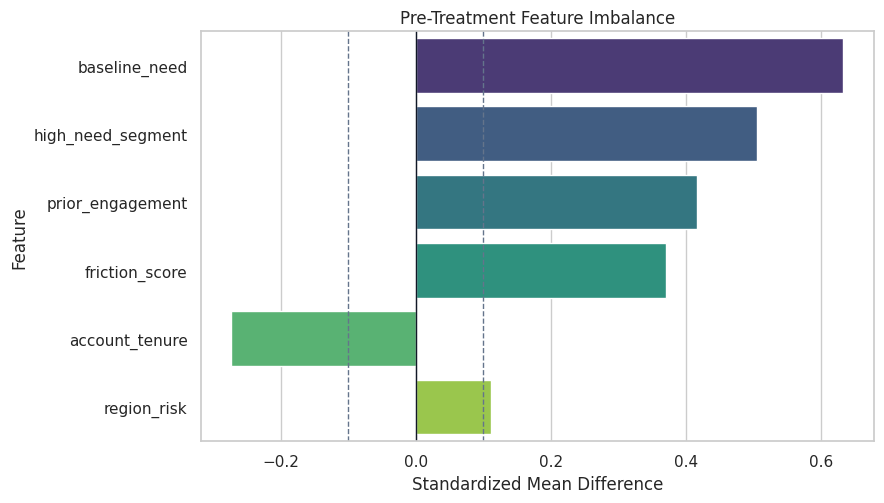

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.2))
sns.barplot(
    data=balance_table,
    x="standardized_mean_difference",
    y="feature",
    hue="feature",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.1, color="#64748b", linestyle="--", linewidth=1)
ax.axvline(-0.1, color="#64748b", linestyle="--", linewidth=1)
ax.set_title("Pre-Treatment Feature Imbalance")
ax.set_xlabel("Standardized Mean Difference")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_covariate_imbalance.png", dpi=160, bbox_inches="tight")
plt.show()


The imbalance plot explains why an unadjusted comparison is not credible. It also previews the role of treatment nuisance models in DML and DR learners.

#### Overlap Check

Overlap asks whether treatment and control units exist in the same feature regions. We fit a simple propensity model to visualize estimated assignment probabilities.

In [9]:
propensity_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1_000, solver="lbfgs"),
)
propensity_model.fit(potential_df[PRE_TREATMENT_FEATURES], potential_df["treatment"])
potential_df["estimated_propensity"] = propensity_model.predict_proba(potential_df[PRE_TREATMENT_FEATURES])[:, 1]

propensity_auc = roc_auc_score(potential_df["treatment"], potential_df["estimated_propensity"])
propensity_summary = potential_df["estimated_propensity"].describe().to_frame("estimated_propensity").reset_index()
propensity_summary = propensity_summary.rename(columns={"index": "summary"})
propensity_summary.loc[len(propensity_summary)] = {"summary": "roc_auc", "estimated_propensity": propensity_auc}

propensity_summary.to_csv(TABLE_DIR / "01_propensity_summary.csv", index=False)
print(f"Estimated propensity ROC AUC: {propensity_auc:.3f}")
display(propensity_summary)


Estimated propensity ROC AUC: 0.752


,summary,estimated_propensity
0,count,"5,000.0000"
1,mean,0.4904
2,std,0.2195
3,min,0.0237
4,25%,0.3182
5,50%,0.4830
6,75%,0.6640
7,max,0.9838
8,roc_auc,0.7523


The treatment model is predictive, confirming that treatment assignment is not random. The distribution still needs to have enough overlap for causal comparison.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->


#### Plot Propensity Overlap

This plot compares estimated propensities for treated and control units. Severe separation would make CATE estimation much more fragile.

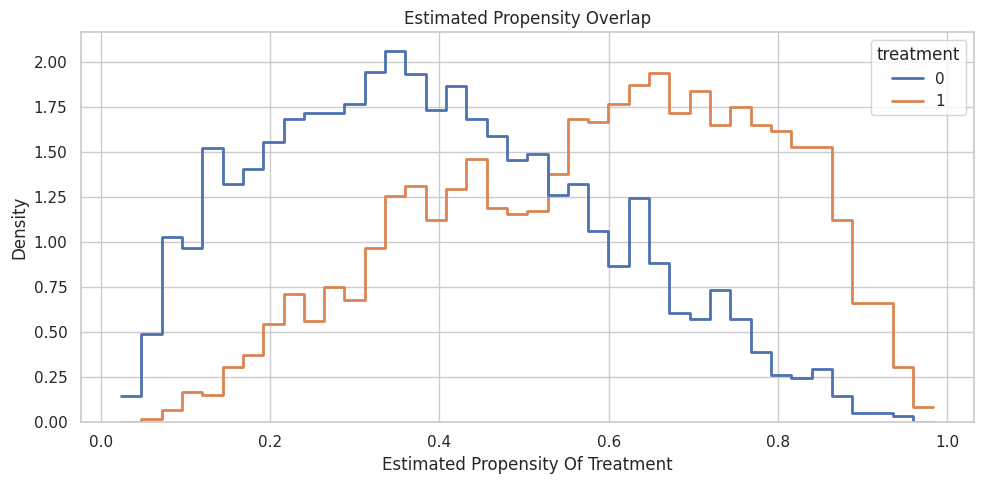

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=potential_df,
    x="estimated_propensity",
    hue="treatment",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=2,
    ax=ax,
)
ax.set_title("Estimated Propensity Overlap")
ax.set_xlabel("Estimated Propensity Of Treatment")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()


The overlap is usable for a worked example. Some tail regions are thinner, which is exactly where individual CATE estimates would be less trustworthy.

#### True CATE Distribution

CATE is a distribution, more than one number. We plot the true synthetic CATE to see how much heterogeneity exists.

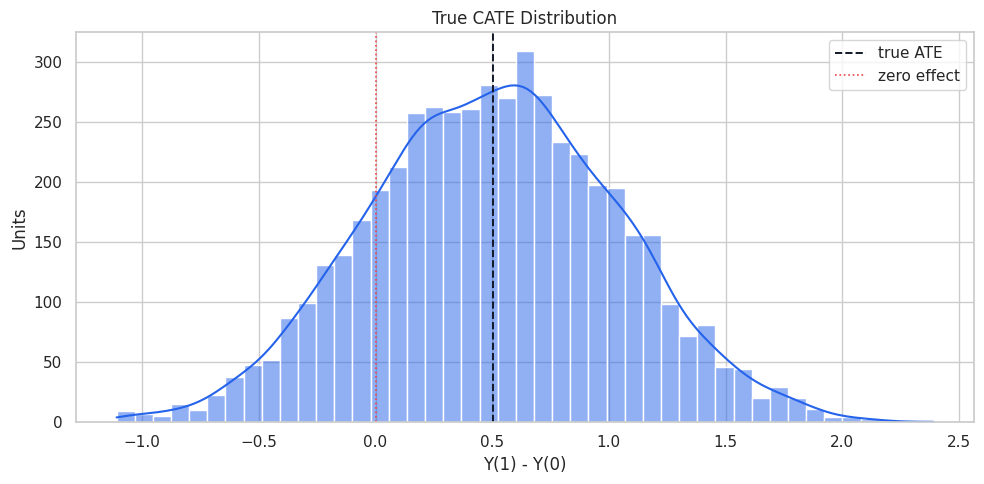

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(potential_df, x="true_cate", bins=45, kde=True, color="#2563eb", ax=ax)
ax.axvline(true_ate, color="#111827", linestyle="--", linewidth=1.4, label="true ATE")
ax.axvline(0, color="#ef4444", linestyle=":", linewidth=1.2, label="zero effect")
ax.set_title("True CATE Distribution")
ax.set_xlabel("Y(1) - Y(0)")
ax.set_ylabel("Units")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_true_cate_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

The distribution makes the core EconML motivation visible. Some units have much larger expected benefit than the average, while a smaller share may have little or negative benefit.



#### Segment-Level CATE

CATE becomes easier to communicate when summarized over meaningful segments. Here we use the high-need segment and friction buckets.

In [12]:
potential_df["friction_bucket"] = pd.qcut(
    potential_df["friction_score"],
    q=4,
    labels=["lowest friction", "low-mid friction", "high-mid friction", "highest friction"],
)
potential_df["need_segment_label"] = np.where(
    potential_df["high_need_segment"] == 1,
    "higher baseline need",
    "lower baseline need",
)

segment_cate = (
    potential_df.groupby(["need_segment_label", "friction_bucket"], observed=True)
    .agg(
        rows=("true_cate", "size"),
        true_cate_mean=("true_cate", "mean"),
        true_cate_median=("true_cate", "median"),
        treatment_rate=("treatment", "mean"),
    )
    .reset_index()
)

segment_cate.to_csv(TABLE_DIR / "01_segment_cate.csv", index=False)
display(segment_cate)


,need_segment_label,friction_bucket,rows,true_cate_mean,true_cate_median,treatment_rate
0,higher baseline need,lowest friction,653,1.2581,1.2277,0.4778
1,higher baseline need,low-mid friction,639,0.9237,0.9496,0.5884
2,higher baseline need,high-mid friction,593,0.6815,0.6849,0.6526
3,higher baseline need,highest friction,651,0.3517,0.3446,0.7296
4,lower baseline need,lowest friction,597,0.6441,0.6322,0.2647
5,lower baseline need,low-mid friction,611,0.3209,0.3194,0.3273
6,lower baseline need,high-mid friction,657,0.0825,0.0819,0.3866
7,lower baseline need,highest friction,599,-0.2585,-0.2428,0.4841


The segment table shows meaningful variation. Higher need tends to raise treatment benefit, while higher friction tends to reduce it in this simulator.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Plot Segment-Level CATE

A heatmap makes the two-way heterogeneity pattern easier to scan.

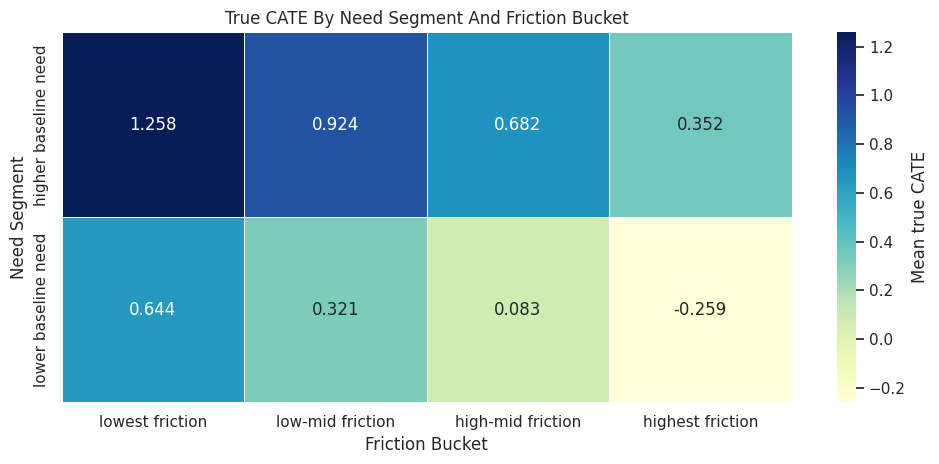

In [13]:
segment_heatmap = segment_cate.pivot(
    index="need_segment_label",
    columns="friction_bucket",
    values="true_cate_mean",
)

fig, ax = plt.subplots(figsize=(10, 4.8))
sns.heatmap(
    segment_heatmap,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Mean true CATE"},
    ax=ax,
)
ax.set_title("True CATE By Need Segment And Friction Bucket")
ax.set_xlabel("Friction Bucket")
ax.set_ylabel("Need Segment")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_segment_cate_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


This plot shows why targeting can matter. Treating every unit the same would ignore large differences in expected benefit.

The decision implication is that estimated gains need to be filtered through uncertainty, cost, support, and operational constraints before becoming actions.
<!-- result-implication-expanded -->


#### CATE Drivers in the Oracle Data

Because true CATE is known, we can regress it on features to show which variables drive heterogeneity. In real data, this would be replaced by model-based explanation of estimated CATE.

In [14]:
oracle_cate_model = sm.OLS(
    potential_df["true_cate"],
    sm.add_constant(potential_df[X_EFFECT_MODIFIERS]),
).fit()

oracle_driver_table = (
    oracle_cate_model.params.rename("coefficient")
    .to_frame()
    .join(oracle_cate_model.bse.rename("standard_error"))
    .reset_index(names="feature")
)

oracle_driver_table.to_csv(TABLE_DIR / "01_oracle_cate_drivers.csv", index=False)
display(oracle_driver_table)


,feature,coefficient,standard_error
0,const,0.2825,0.0007
1,baseline_need,0.0995,0.0006
2,prior_engagement,0.2500,0.0003
3,friction_score,-0.3498,0.0003
4,high_need_segment,0.4510,0.0011


The oracle regression recovers the simulator logic: high need and prior engagement raise the effect, while friction lowers it. Later notebooks will try to learn this from observed outcomes only.

#### Naive Segment Effects versus True Segment Effects

A common first attempt is to compute treated-control differences inside segments. This can still be biased if treatment is confounded within those segments.

In [15]:
naive_segment_rows = []
for segment_name, segment_df in potential_df.groupby("need_segment_label"):
    treated_mean = segment_df.loc[segment_df["treatment"] == 1, "observed_outcome"].mean()
    control_mean = segment_df.loc[segment_df["treatment"] == 0, "observed_outcome"].mean()
    naive_difference = treated_mean - control_mean
    true_segment_effect = segment_df["true_cate"].mean()
    naive_segment_rows.append(
        {
            "segment": segment_name,
            "rows": len(segment_df),
            "naive_treated_control_difference": naive_difference,
            "true_segment_cate": true_segment_effect,
            "bias": naive_difference - true_segment_effect,
        }
    )

naive_segment_effects = pd.DataFrame(naive_segment_rows)
naive_segment_effects.to_csv(TABLE_DIR / "01_naive_segment_effects.csv", index=False)
display(naive_segment_effects)


,segment,rows,naive_treated_control_difference,true_segment_cate,bias
0,higher baseline need,2536,1.0013,0.8063,0.1949
1,lower baseline need,2464,0.4524,0.1948,0.2576


Even segment-level comparisons can be biased. Segmenting does not automatically solve confounding; it only changes the population being compared.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->


#### A Simple Interaction Regression Bridge

Before using EconML, we can fit a transparent baseline: an outcome regression with treatment-feature interactions. This serves a different role than the final estimator. It shows the shape of a CATE model.

In [16]:
interaction_df = potential_df.copy()
for feature in X_EFFECT_MODIFIERS:
    interaction_df[f"treatment_x_{feature}"] = interaction_df["treatment"] * interaction_df[feature]

interaction_features = (
    ["treatment"]
    + PRE_TREATMENT_FEATURES
    + [f"treatment_x_{feature}" for feature in X_EFFECT_MODIFIERS]
)

interaction_model = sm.OLS(
    interaction_df["observed_outcome"],
    sm.add_constant(interaction_df[interaction_features]),
).fit()

interaction_coefficients = (
    interaction_model.params.rename("coefficient")
    .to_frame()
    .join(interaction_model.bse.rename("standard_error"))
    .reset_index(names="term")
)
interaction_coefficients.to_csv(TABLE_DIR / "01_interaction_regression_coefficients.csv", index=False)
display(interaction_coefficients.head(15))


,term,coefficient,standard_error
0,const,-0.0022,0.0288
1,treatment,0.2854,0.0404
2,baseline_need,0.6565,0.0235
3,prior_engagement,0.3428,0.0142
4,account_tenure,-0.2604,0.0101
5,friction_score,-0.3528,0.0142
6,region_risk,-0.1553,0.0210
7,high_need_segment,-0.0097,0.0462
8,treatment_x_baseline_need,0.0840,0.0337
9,treatment_x_prior_engagement,0.2638,0.0202


The interaction terms are a simple way to let treatment effects vary with features. EconML estimators generalize this idea with more careful nuisance modeling and flexible final stages.

#### Recover CATE from the Interaction Regression

For the interaction model, the estimated CATE is the treatment coefficient plus the treatment-feature interaction terms for each row.

In [17]:
base_treatment_coef = interaction_model.params["treatment"]
estimated_cate_interaction = np.full(len(interaction_df), base_treatment_coef)

for feature in X_EFFECT_MODIFIERS:
    estimated_cate_interaction += interaction_model.params[f"treatment_x_{feature}"] * interaction_df[feature]

interaction_df["estimated_cate_interaction"] = estimated_cate_interaction

interaction_metrics = pd.DataFrame(
    [
        {"metric": "true ATE", "value": interaction_df["true_cate"].mean()},
        {"metric": "interaction-regression estimated ATE", "value": interaction_df["estimated_cate_interaction"].mean()},
        {"metric": "CATE correlation with truth", "value": np.corrcoef(interaction_df["true_cate"], interaction_df["estimated_cate_interaction"])[0, 1]},
        {"metric": "CATE RMSE", "value": np.sqrt(mean_squared_error(interaction_df["true_cate"], interaction_df["estimated_cate_interaction"]))},
    ]
)

interaction_metrics.to_csv(TABLE_DIR / "01_interaction_cate_metrics.csv", index=False)
display(interaction_metrics)


,metric,value
0,true ATE,0.5050
1,interaction-regression estimated ATE,0.5087
2,CATE correlation with truth,0.9982
3,CATE RMSE,0.0328


The simple interaction model performs well here because the simulator is mostly linear. Later notebooks will show why we need stronger tools when nuisance functions or CATE patterns are more complex.

#### Plot Estimated versus True CATE for the Simple Baseline

This plot checks whether the interaction regression learns the treatment-effect ranking, more than the average.

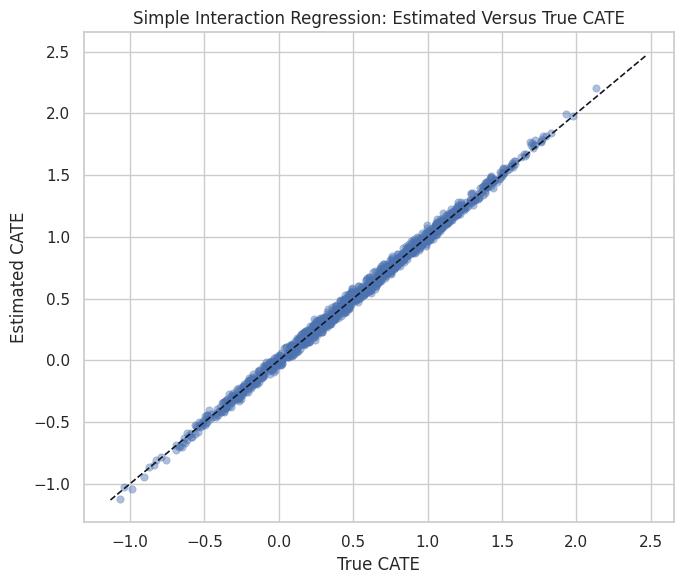

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=interaction_df.sample(1_200, random_state=RANDOM_SEED),
    x="true_cate",
    y="estimated_cate_interaction",
    alpha=0.45,
    s=28,
    edgecolor=None,
    ax=ax,
)
min_value = min(interaction_df["true_cate"].min(), interaction_df["estimated_cate_interaction"].min())
max_value = max(interaction_df["true_cate"].max(), interaction_df["estimated_cate_interaction"].max())
ax.plot([min_value, max_value], [min_value, max_value], color="#111827", linestyle="--", linewidth=1.2)
ax.set_title("Simple Interaction Regression: Estimated Versus True CATE")
ax.set_xlabel("True CATE")
ax.set_ylabel("Estimated CATE")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_interaction_estimated_vs_true_cate.png", dpi=160, bbox_inches="tight")
plt.show()


The baseline recovers the broad pattern in this friendly simulation. EconML becomes more valuable as the data-generating process becomes less friendly.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->




#### CATE as a Treatment-Targeting Signal

CATE estimates are often used to prioritize treatment. With oracle potential outcomes, we can compare simple targeting policies using the true treatment effects.

In [19]:
# Define reusable helpers for the CATE As A Treatment-Targeting Signal section.
policy_df = potential_df.copy()
policy_df["oracle_rank"] = policy_df["true_cate"].rank(ascending=False, method="first")
policy_df["treat_top_30_percent"] = (policy_df["oracle_rank"] <= 0.30 * len(policy_df)).astype(int)
policy_df["treat_positive_effect_only"] = (policy_df["true_cate"] > 0).astype(int)
policy_df["treat_random_30_percent"] = rng.binomial(1, 0.30, size=len(policy_df))


def oracle_policy_value(treatment_rule):
    """
    Idea: Evaluate a policy against oracle treatment effects available only in the simulation.
    
    Parameters
    ----------
    treatment_rule : object
        Context-specific input used for treatment rule in this helper.
    
    Returns
    -------
    float
        Oracle mean policy value computed from simulated treatment effects.
    """
    return np.mean(np.where(treatment_rule == 1, policy_df["y1"], policy_df["y0"]))

policy_summary = pd.DataFrame(
    [
        {"policy": "treat none", "treated_share": 0.0, "oracle_value": oracle_policy_value(np.zeros(len(policy_df)))},
        {"policy": "treat everyone", "treated_share": 1.0, "oracle_value": oracle_policy_value(np.ones(len(policy_df)))},
        {"policy": "random 30 percent", "treated_share": policy_df["treat_random_30_percent"].mean(), "oracle_value": oracle_policy_value(policy_df["treat_random_30_percent"])},
        {"policy": "oracle top 30 percent by CATE", "treated_share": policy_df["treat_top_30_percent"].mean(), "oracle_value": oracle_policy_value(policy_df["treat_top_30_percent"])},
        {"policy": "oracle positive CATE only", "treated_share": policy_df["treat_positive_effect_only"].mean(), "oracle_value": oracle_policy_value(policy_df["treat_positive_effect_only"])},
    ]
)
policy_summary["value_lift_vs_treat_none"] = policy_summary["oracle_value"] - policy_summary.loc[policy_summary["policy"] == "treat none", "oracle_value"].iloc[0]

policy_summary.to_csv(TABLE_DIR / "01_oracle_policy_summary.csv", index=False)
display(policy_summary)


,policy,treated_share,oracle_value,value_lift_vs_treat_none
0,treat none,0.0000,-0.0662,0.0000
1,treat everyone,1.0000,0.4388,0.5050
2,random 30 percent,0.2972,0.0854,0.1516
3,oracle top 30 percent by CATE,0.3000,0.2721,0.3383
4,oracle positive CATE only,0.8238,0.4881,0.5543


The oracle CATE policies outperform random targeting because they concentrate treatment where benefit is highest. Real CATE models try to approximate this ranking without observing the oracle truth.



#### Plot Oracle Policy Values

The policy plot shows why heterogeneity matters operationally. A good treatment rule can create more value with fewer treated units.

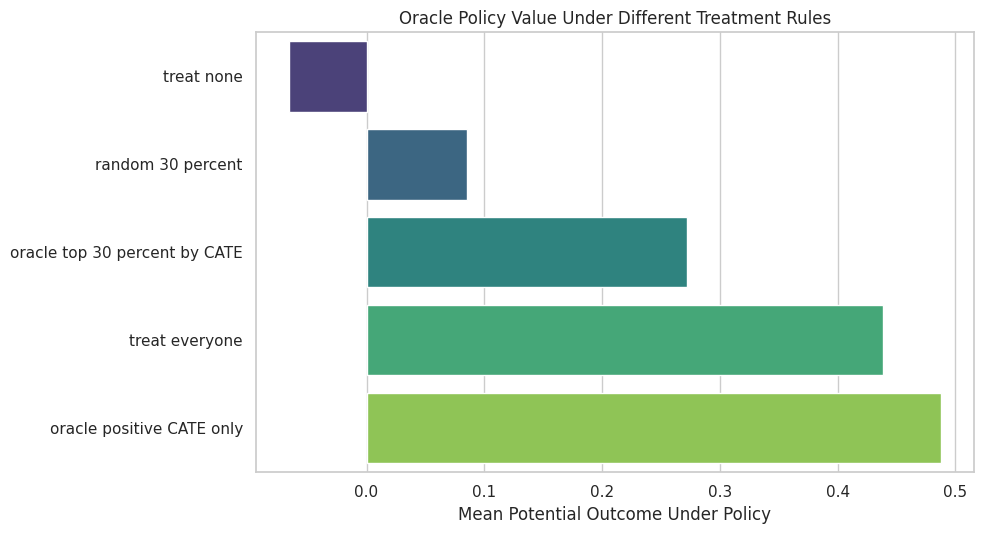

In [20]:
plot_policy_summary = policy_summary.sort_values("oracle_value")

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=plot_policy_summary,
    x="oracle_value",
    y="policy",
    hue="policy",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.set_title("Oracle Policy Value Under Different Treatment Rules")
ax.set_xlabel("Mean Potential Outcome Under Policy")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "01_oracle_policy_values.png", dpi=160, bbox_inches="tight")
plt.show()


The oracle policy serves a different role than achievable in real data. It gives the north star for treatment-targeting notebooks: learn a ranking that improves policy value without relying on hidden truth.

#### Why EconML Needs X and W

This table connects the foundation concepts to the data roles used by EconML estimators.

In [21]:
# Save the artifacts produced by the Why EconML Needs X And W section.
x_w_role_summary = pd.DataFrame(
    [
        {
            "role": "X: effect modifiers",
            "columns in this lesson": ", ".join(X_EFFECT_MODIFIERS),
            "why it matters": "CATE is modeled as a function of these features.",
        },
        {
            "role": "W: controls",
            "columns in this lesson": ", ".join(W_CONTROLS),
            "why it matters": "Controls help nuisance models adjust for confounding.",
        },
        {
            "role": "T: treatment",
            "columns in this lesson": "treatment",
            "why it matters": "The intervention whose effect is estimated.",
        },
        {
            "role": "Y: outcome",
            "columns in this lesson": "observed_outcome",
            "why it matters": "Only the factual outcome is observed in real data.",
        },
    ]
)

x_w_role_summary.to_csv(TABLE_DIR / "01_x_w_role_summary.csv", index=False)
display(x_w_role_summary)


,role,columns in this lesson,why it matters
0,X: effect modifiers,"baseline_need, prior_engagement, friction_score, high_need_segment",CATE is modeled as a function of these features.
1,W: controls,"account_tenure, region_risk",Controls help nuisance models adjust for confounding.
2,T: treatment,treatment,The intervention whose effect is estimated.
3,Y: outcome,observed_outcome,Only the factual outcome is observed in real data.


The same variable can sometimes be both a confounder and an effect modifier. The `X` and `W` split is a modeling choice that should follow the causal question.



#### Foundation Checklist

Before fitting an EconML estimator, this checklist should be clear. It keeps CATE modeling connected to causal design rather than pure prediction.

In [22]:
foundation_checklist = pd.DataFrame(
    [
        {"check": "Treatment and outcome are defined", "status in this lesson": "treatment and observed_outcome"},
        {"check": "Potential-outcome estimand is named", "status in this lesson": "ATE, ATT, ATC, and CATE"},
        {"check": "Observed features are pre-treatment", "status in this lesson": "baseline features only"},
        {"check": "Confounding is diagnosed", "status in this lesson": "covariate balance table and plot"},
        {"check": "Overlap is diagnosed", "status in this lesson": "propensity summary and histogram"},
        {"check": "Effect modifiers are named", "status in this lesson": ", ".join(X_EFFECT_MODIFIERS)},
        {"check": "Controls are named", "status in this lesson": ", ".join(W_CONTROLS)},
        {"check": "A simple baseline is available", "status in this lesson": "interaction regression CATE baseline"},
        {"check": "Targeting use case is explicit", "status in this lesson": "oracle policy-value comparison"},
    ]
)

foundation_checklist.to_csv(TABLE_DIR / "01_foundation_checklist.csv", index=False)
display(foundation_checklist)


,check,status in this lesson
0,Treatment and outcome are defined,treatment and observed_outcome
1,Potential-outcome estimand is named,"ATE, ATT, ATC, and CATE"
2,Observed features are pre-treatment,baseline features only
3,Confounding is diagnosed,covariate balance table and plot
4,Overlap is diagnosed,propensity summary and histogram
5,Effect modifiers are named,"baseline_need, prior_engagement, friction_score, high_need_segment"
6,Controls are named,"account_tenure, region_risk"
7,A simple baseline is available,interaction regression CATE baseline
8,Targeting use case is explicit,oracle policy-value comparison


The checklist is intentionally estimator-agnostic. It should be completed before choosing LinearDML, CausalForestDML, DRLearner, or any other method.

The causal implication is indirect but important: these diagnostics tell us whether the modeling stage is stable enough to support the causal estimate.
<!-- result-implication-expanded -->


#### Final Summary

This lesson introduced the potential-outcomes foundation for the EconML series.

Key takeaways:

- Real data reveal only one potential outcome per unit.
- ATE, ATT, ATC, and CATE answer different population questions.
- Raw treated-control differences can be badly biased in observational data.
- CATE is useful because treatment effects vary across feature-defined groups.
- Segment summaries and policy values show why heterogeneity matters for decisions.
- Later EconML estimators try to recover CATE from observed data using nuisance models, effect modifiers, and assumptions about confounding and overlap.

The next notebook moves from these foundations to double machine learning: residualization, orthogonalization, nuisance models, and cross-fitting.